<a href="https://colab.research.google.com/github/Vasuvarma37/Cyber-Attack-Detection/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyber Attack Detection
Practice Notebook

## 1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [24]:
df = pd.read_csv(
    "/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
)

df.columns = df.columns.str.strip()

print(df.shape)

(225745, 79)


### Dataset Summary

The CICIDS2017 dataset contains network traffic flow records used for intrusion detection research.

Initial Shape:
- Rows: 225,745
- Columns: 79

## 3. Exploratory Data Analysis

In [26]:
print(df.info()) # to understand the dataset for data cleaning


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             225745 non-null  int64  
 1   Flow Duration                225745 non-null  int64  
 2   Total Fwd Packets            225745 non-null  int64  
 3   Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets  225745 non-null  int64  
 5   Total Length of Bwd Packets  225745 non-null  int64  
 6   Fwd Packet Length Max        225745 non-null  int64  
 7   Fwd Packet Length Min        225745 non-null  int64  
 8   Fwd Packet Length Mean       225745 non-null  float64
 9   Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max        225745 non-null  int64  
 11  Bwd Packet Length Min        225745 non-null  int64  
 12  Bwd Packet Length Mean       225745 non-null  float64
 13 

In [27]:
print(df.head())

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6                      6            

In [28]:
print(df.describe())

       Destination Port  Flow Duration  Total Fwd Packets  \
count      225745.00000   2.257450e+05      225745.000000   
mean         8879.61946   1.624165e+07           4.874916   
std         19754.64740   3.152437e+07          15.422874   
min             0.00000  -1.000000e+00           1.000000   
25%            80.00000   7.118000e+04           2.000000   
50%            80.00000   1.452333e+06           3.000000   
75%            80.00000   8.805237e+06           5.000000   
max         65532.00000   1.199999e+08        1932.000000   

       Total Backward Packets  Total Length of Fwd Packets  \
count           225745.000000                225745.000000   
mean                 4.572775                   939.463346   
std                 21.755356                  3249.403484   
min                  0.000000                     0.000000   
25%                  1.000000                    26.000000   
50%                  4.000000                    30.000000   
75%             

MISSING VALUES

In [29]:
df.isnull().sum().sort_values(
    ascending=False
)


,0
Flow Bytes/s,4
Flow Duration,0
Destination Port,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


HEATMAP

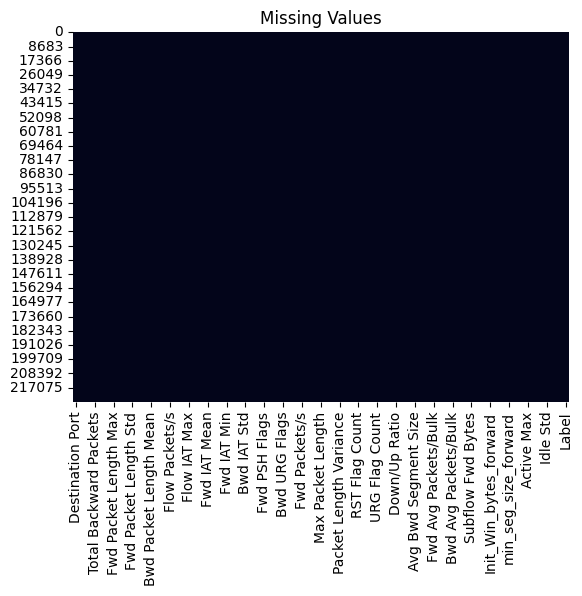

In [30]:
sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

Duplicate Analysis

Data Cleaning

In [34]:
df = df.dropna()
df = df.drop_duplicates()

print(df.shape)

(223108, 79)


label distribution

In [35]:
df["Label"].value_counts()


,count
Label,
DDoS,128016
BENIGN,95092


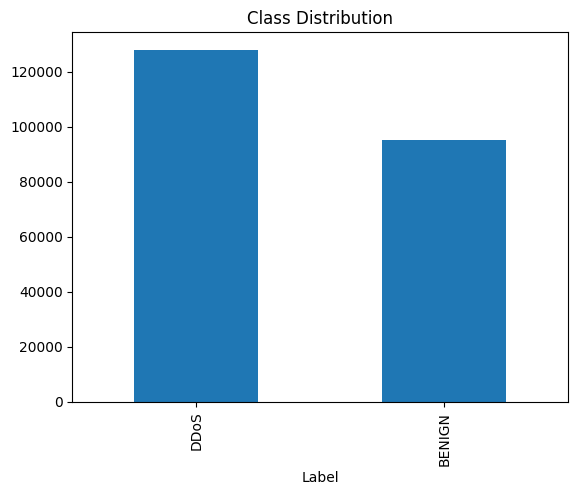

In [36]:
df["Label"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Class Distribution"
)

plt.show()

In [41]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Label"] = encoder.fit_transform(
    df["Label"]
)

encoder.classes_
print(encoder.classes_)
print(df["Label"].value_counts())

[0 1]
Label
1    128016
0     95092
Name: count, dtype: int64


## 5. Correlation Analysis

In [38]:
corr = df.corr(
    numeric_only=True
)

corr["Label"].sort_values(
    ascending=False
).head(15)

,Label
Label,1.000000
Bwd Packet Length Mean,0.599947
Avg Bwd Segment Size,0.599947
Bwd Packet Length Max,0.573836
Bwd Packet Length Std,0.572761
Packet Length Mean,0.448303
Average Packet Size,0.447603
Packet Length Std,0.437702
Max Packet Length,0.408084
Packet Length Variance,0.403203


**Correlation Heatmap**

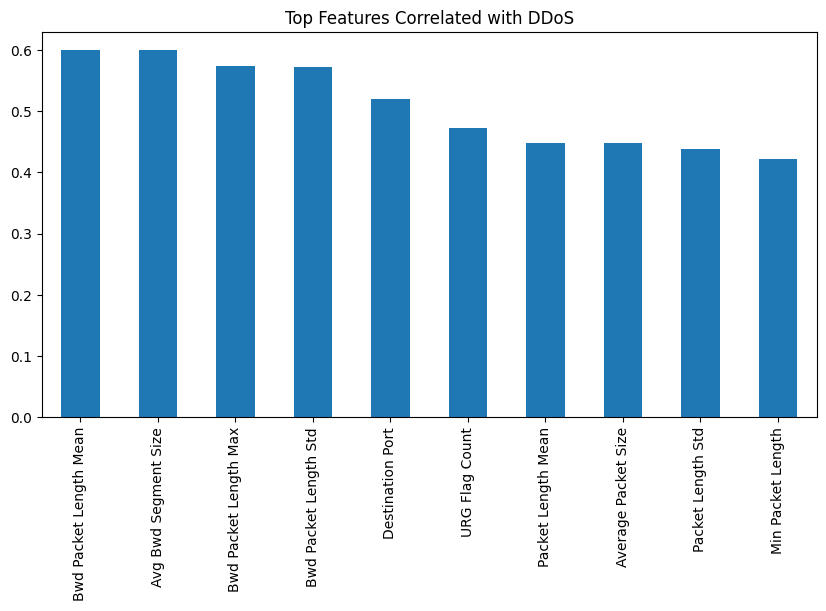

In [39]:
top_corr = corr["Label"].abs().sort_values(
    ascending=False
)[1:11]

plt.figure(figsize=(10,5))

top_corr.plot(
    kind="bar"
)

plt.title(
    "Top Features Correlated with DDoS"
)

plt.show()

Correlation Heatmap

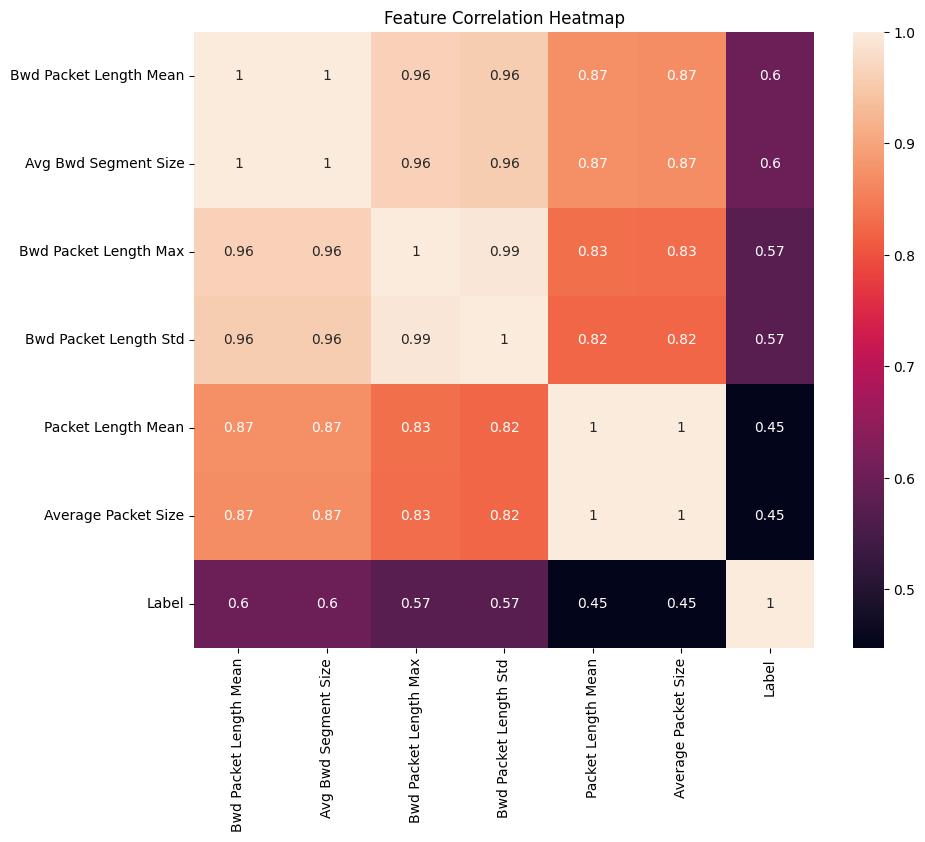

In [40]:
top_features = [
    'Bwd Packet Length Mean',
    'Avg Bwd Segment Size',
    'Bwd Packet Length Max',
    'Bwd Packet Length Std',
    'Packet Length Mean',
    'Average Packet Size',
    'Label'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()

# Conclusion

The CICIDS2017 dataset was successfully cleaned and analyzed.

Key findings:

- DDoS traffic constitutes the majority of observations.
- Packet-length-related features show the strongest relationship with attack behavior.
- The dataset is suitable for supervised machine learning classification.

The cleaned dataset will be used in the next notebook for model training and evaluation.

In [42]:
df.to_csv(
    "cleaned_cicids2017.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
